Best MI percentile:
Asset es1_logret: 90
Asset vg1_logret: 86
Asset z1_logret: 74
Asset rx1_logret: 58
Asset gc1_logret: 76
Asset co1_logret: 68
Asset hg1_logret: 86

Optimized Portfolio Sharpe: 0.0560
Benchmark Portfolio Sharpe: 0.0667
Optimized Portfolio Max Drawdown: 23.23%
Benchmark Portfolio Max Drawdown: 29.61%
Final Optimized Cumulative Return: 1.3539
Final Benchmark Cumulative Return: 1.4073
S&P Sharpe Ratio: 0.12


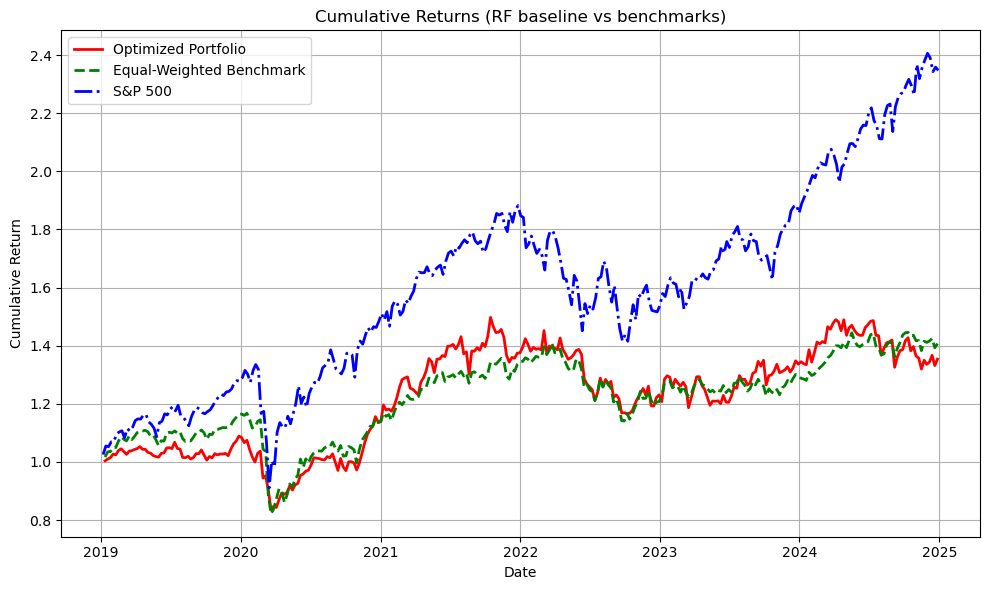


In-Sample Performance Metrics per Asset:
                 MSE        R2  Directional Accuracy  Spearman  \
es1_logret  0.000199  0.344253              0.725753  0.679928   
vg1_logret  0.000389  0.291510              0.739130  0.677399   
z1_logret   0.000265  0.427528              0.789298  0.772380   
rx1_logret  0.000037  0.319866              0.809365  0.724341   
gc1_logret  0.000202  0.529696              0.816054  0.806839   
co1_logret  0.000929  0.460281              0.789298  0.806169   
hg1_logret  0.000281  0.614606              0.862876  0.908086   

            Best MI percentile  
es1_logret                90.0  
vg1_logret                86.0  
z1_logret                 74.0  
rx1_logret                58.0  
gc1_logret                76.0  
co1_logret                68.0  
hg1_logret                86.0  

Out-of-Sample Prediction Metrics per Asset:
                 MSE        R2  Directional Accuracy  Spearman
es1_logret  0.000717 -0.132602              0.418530  0.0

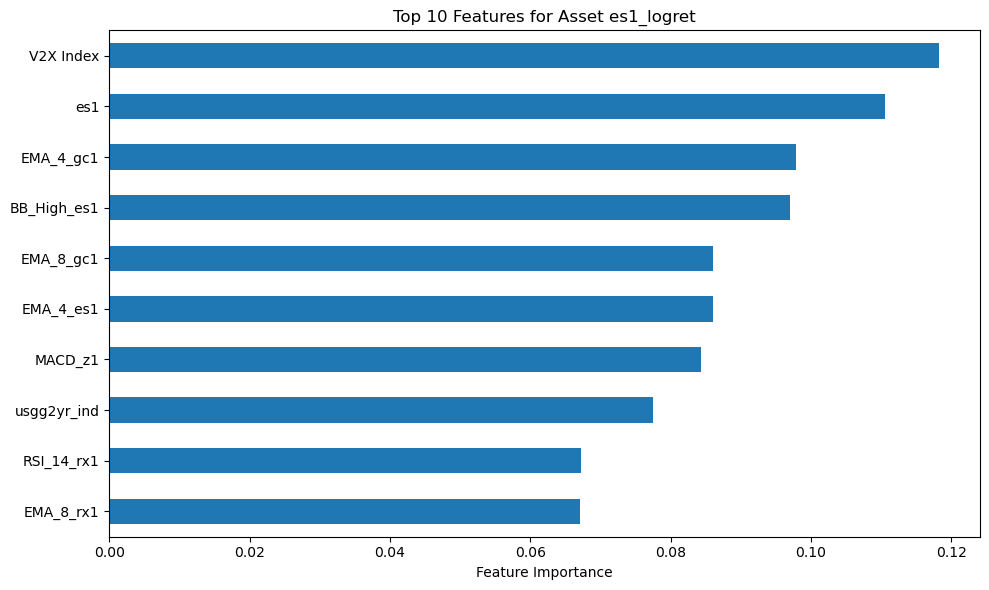


Top 10 features for asset vg1_logret:
EMA_4_vg1          0.086364
V2X Index          0.079728
EMA_4_co1          0.077867
co1                0.074293
BB_Low_z1          0.070640
EMA_8_es1          0.069444
SKEW Index         0.061228
EMA_8_co1          0.060482
BB_High_es1        0.057504
MACD_Signal_gc1    0.054259
dtype: float64



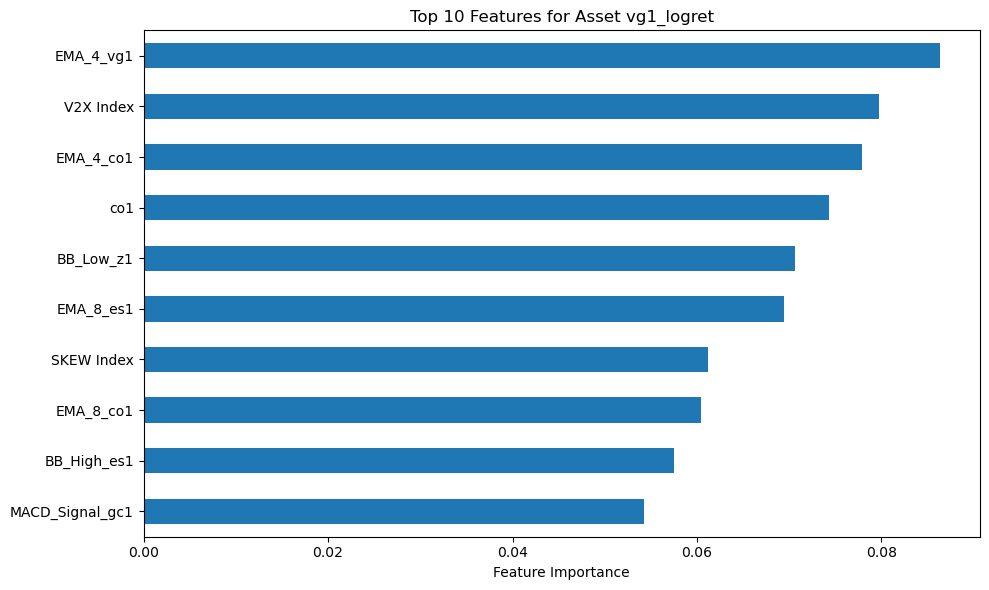


Top 10 features for asset z1_logret:
es1                0.057968
z1                 0.057290
MACD_rx1           0.048617
HV_20_es1          0.048517
BB_High_gc1        0.046621
EMA_8_z1           0.046558
MACD_co1           0.046334
EMA_4_vg1          0.044669
MACD_Signal_hg1    0.044593
MACD_hg1           0.039191
dtype: float64



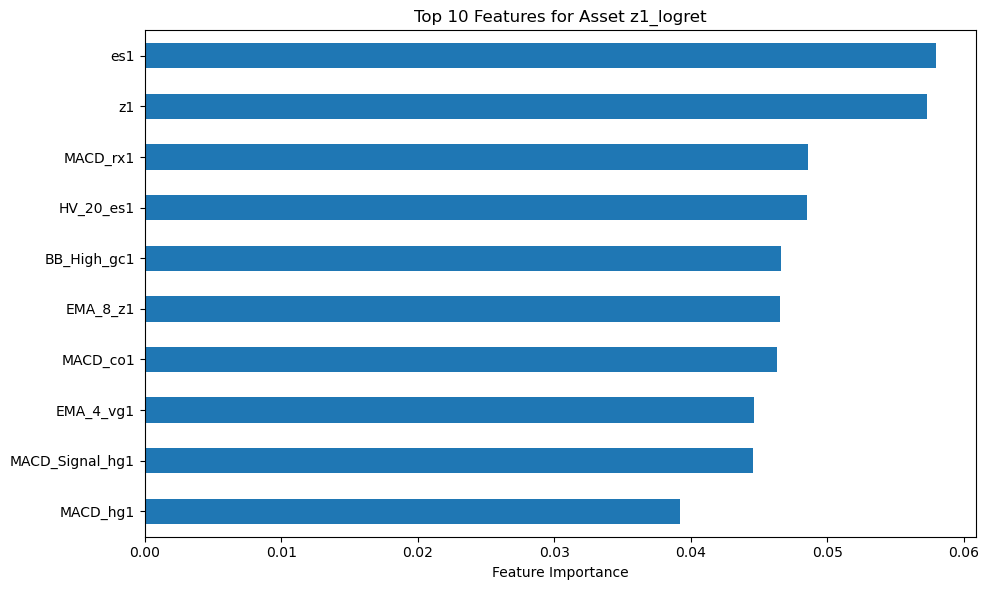


Top 10 features for asset rx1_logret:
MACD_es1              0.043153
rx1                   0.034604
usgg2yr_ind           0.031947
gc1                   0.029858
ROC_10_co1            0.028257
EMA_24_gc1            0.027014
BDIY Index_logdiff    0.026956
ROC_10_rx1            0.025309
EMA_4_gc1             0.025131
EMA_4_hg1             0.025088
dtype: float64



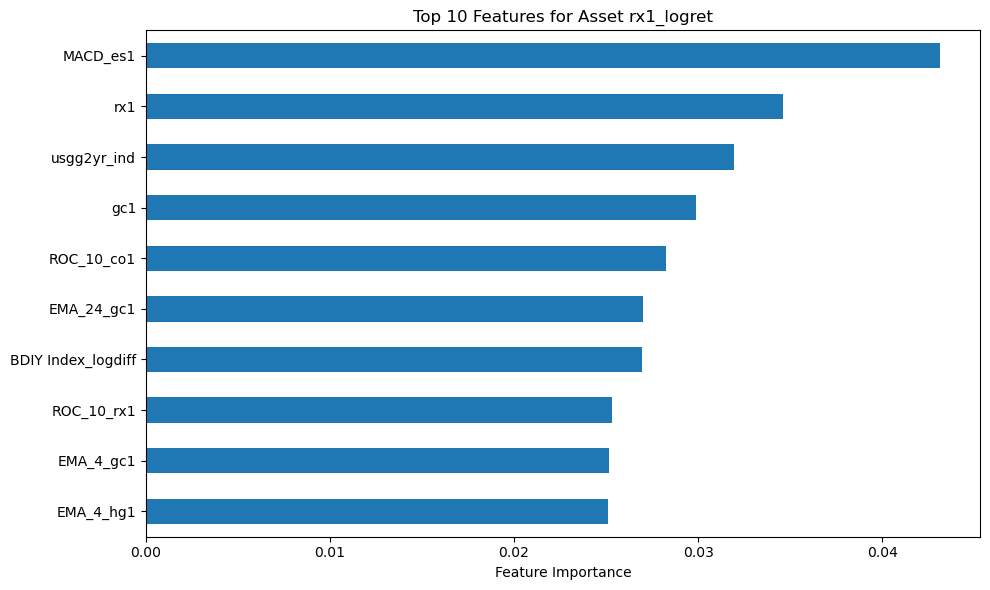


Top 10 features for asset gc1_logret:
gc1                   0.107271
EMA_4_gc1             0.068757
EMA_4_z1              0.062336
itrx_xover_cdsi_5y    0.047724
BB_Low_gc1            0.045068
BB_High_rx1           0.041747
co1                   0.041718
MACD_Signal_rx1       0.041670
V2X Index             0.038675
EMA_8_z1              0.037295
dtype: float64



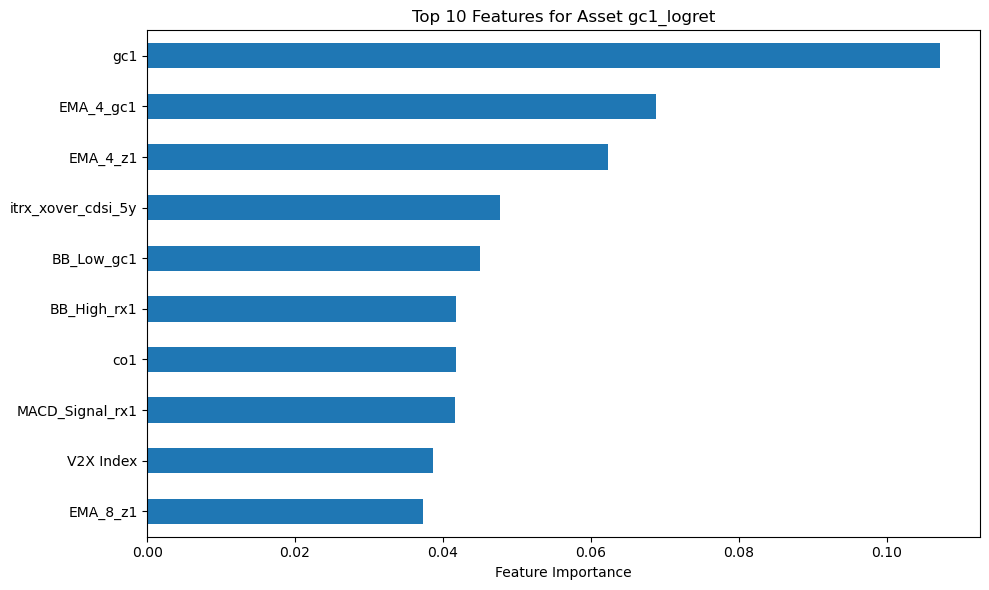


Top 10 features for asset co1_logret:
gdbr_spread        0.039063
gdbr2_ind          0.038566
co1                0.037734
BB_Low_co1         0.036693
EMA_24_hg1         0.036303
EMA_8_co1          0.035394
RSI_14_co1         0.034626
EMA_24_es1         0.032868
MOVE Index_diff    0.032098
EMA_4_rx1          0.030956
dtype: float64



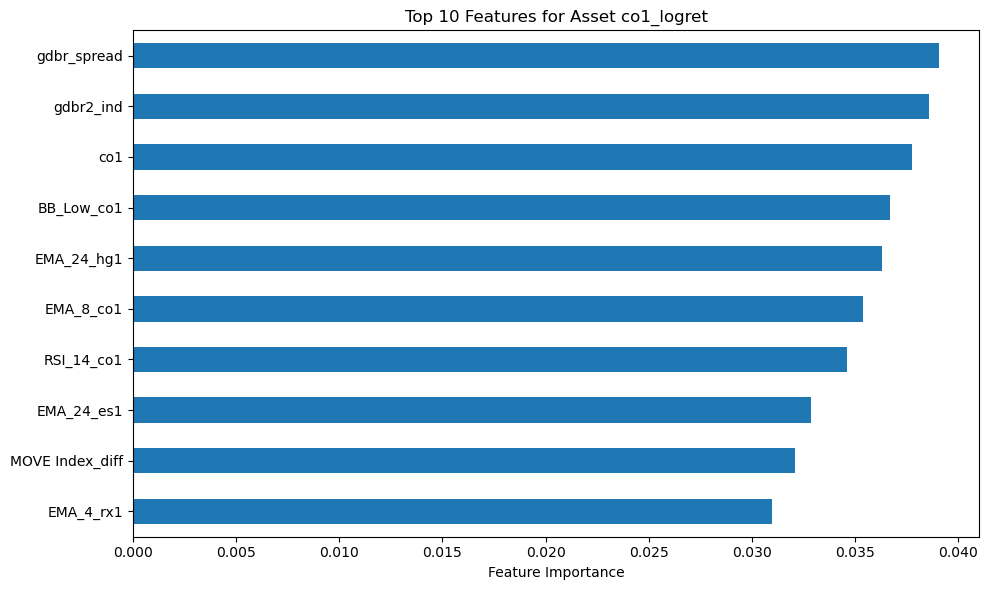


Top 10 features for asset hg1_logret:
MACD_hg1           0.076336
V2X Index          0.075422
vix_ind            0.073064
hg1                0.072383
RSI_14_vg1         0.066318
EMA_8_rx1          0.064414
MACD_Signal_z1     0.063168
BB_Low_co1         0.060798
MACD_Signal_vg1    0.060389
MACD_gc1           0.058327
dtype: float64



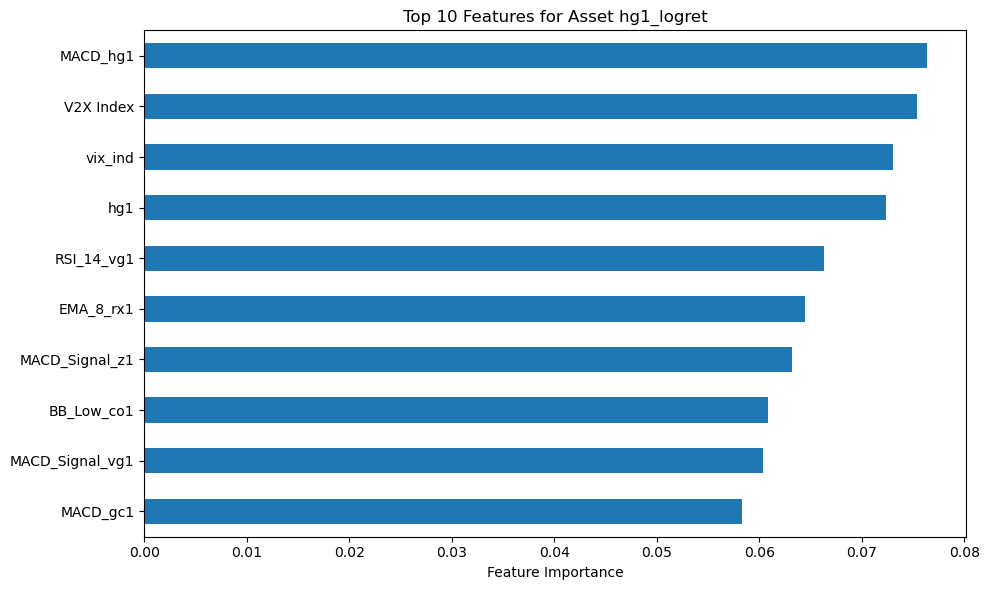

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.feature_selection import mutual_info_regression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import time
import os
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

start_time = time.time()

###############################################################################
# 1. CVaR, Objective
###############################################################################
def compute_cvar(historical_returns, weights, alpha=0.9):
    port_returns = np.dot(historical_returns, weights)
    sorted_returns = np.sort(port_returns)
    cutoff = int(np.floor((1 - alpha) * len(sorted_returns)))
    cutoff = max(cutoff, 0)
    worst_returns = sorted_returns[:cutoff+1]
    cvar = np.mean(worst_returns) if len(worst_returns) > 0 else sorted_returns[cutoff]
    return cvar

def cvar_objective(weights, predicted_returns, historical_returns, alpha=0.9, lambda_reg=0.01):
    eps = 1e-8
    port_return = np.dot(weights, predicted_returns)
    port_cvar = compute_cvar(historical_returns, weights, alpha=alpha)
    return -port_return / (abs(port_cvar) + eps) + lambda_reg * np.sum(weights**2)

###############################################################################
# 2. Random forest hyperparameter space
###############################################################################
rf_param_space = {
    'n_estimators': Integer(70, 125),
    'max_depth': Integer(8, 40),
    'min_samples_split': Integer(4, 15),
    'min_samples_leaf': Integer(3, 10),
    'max_features': Real(0.03, 0.4, prior='uniform'),
    'bootstrap': Categorical([True, False]),
    'criterion': Categorical(['friedman_mse'])
}

###############################################################################
# 3. Data and train/test
###############################################################################
price_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\broader_weekly_data_filled.xlsx',
    parse_dates=["date"],
    index_col="date"
)

filtered_returns = price_data.iloc[:, :7]
filtered_features = price_data.iloc[:, 7:]

train_start_date = '2013-04-01'
train_end_date   = '2018-12-31'
test_start_date  = '2019-01-01'
test_end_date    = '2025-01-01'

train_returns = filtered_returns.loc[train_start_date:train_end_date]
train_features = filtered_features.loc[train_start_date:train_end_date]
test_returns = filtered_returns.loc[test_start_date:test_end_date]
test_features = filtered_features.loc[test_start_date:test_end_date]

all_test_dates = test_returns.index

###############################################################################
# 4. Scaling
###############################################################################
scaler = StandardScaler()
train_features_scaled = pd.DataFrame(
    scaler.fit_transform(train_features),
    index=train_features.index,
    columns=train_features.columns
)
test_features_scaled = pd.DataFrame(
    scaler.transform(test_features),
    index=test_features.index,
    columns=test_features.columns
)

###############################################################################
# 5. Training targets
###############################################################################
#predict returns at time t+1 using features at time t
train_returns_target = train_returns.shift(-1).dropna()
train_features_aligned = train_features_scaled.loc[train_returns_target.index]

###############################################################################
# 6. Adaptive feature selection & training, MI percentile Grid Search
###############################################################################
rf_models = {}
selected_features = {}
in_sample_metrics = {}
best_params_tracker = {}

candidate_percentiles = list(range(50, 91, 2))

for asset in train_returns_target.columns:
    mi_scores = mutual_info_regression(train_features_aligned, train_returns_target[asset], random_state=42)
    best_cv_score = -np.inf 
    best_threshold = None
    best_model_for_asset = None
    best_features = None

    for percentile in candidate_percentiles:
        threshold_value = np.percentile(mi_scores, percentile)
        keep_idxs = np.where(mi_scores >= threshold_value)[0]
        if len(keep_idxs) == 0:
            continue

        features_tmp = train_features_aligned.columns[keep_idxs]
        X_train = train_features_aligned[features_tmp].values
        y_train = train_returns_target[asset].values

        if X_train.shape[0] > 0 and X_train.shape[1] > 0:
            opt = BayesSearchCV(
                RandomForestRegressor(random_state=42),
                rf_param_space,
                n_iter=25,
                cv=TimeSeriesSplit(n_splits=3),
                n_jobs=-1,
                scoring='neg_mean_squared_error',
                random_state=42
            )
            opt.fit(X_train, y_train)
            if opt.best_score_ > best_cv_score:
                best_cv_score = opt.best_score_
                best_threshold = percentile
                best_model_for_asset = opt.best_estimator_
                best_features = features_tmp
                best_params_tracker[asset] = opt.best_params_

    # Save the best
    if best_features is not None:
        selected_features[asset] = best_features
        rf_models[asset] = best_model_for_asset
        X_train_best = train_features_aligned[best_features].values
        y_train = train_returns_target[asset].values
        y_train_pred = best_model_for_asset.predict(X_train_best)
        in_sample_metrics[asset] = {
            "MSE": mean_squared_error(y_train, y_train_pred),
            "R2": r2_score(y_train, y_train_pred),
            "Directional Accuracy": np.mean(np.sign(y_train) == np.sign(y_train_pred)),
            "Spearman": spearmanr(y_train, y_train_pred)[0],
            "Best MI percentile": best_threshold
        }

print("Best MI percentile:")
for asset, metrics in in_sample_metrics.items():
    print(f"Asset {asset}: {metrics['Best MI percentile']}")

###############################################################################
# 7. Out-of-sample predictions & metrics
###############################################################################
predictions = pd.DataFrame(index=test_features_scaled.index, columns=test_returns.columns)
for asset in test_returns.columns:
    if asset in rf_models and rf_models[asset] is not None:
        X_test = test_features_scaled[selected_features[asset]].values
        predictions[asset] = rf_models[asset].predict(X_test)
    else:
        predictions[asset] = 0.0

out_sample_metrics = {}
for asset in test_returns.columns:
    y_true = test_returns[asset]
    y_pred = predictions[asset]
    
    mse_val = mean_squared_error(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)
    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    spearman_corr, _ = spearmanr(y_true, y_pred)
    
    out_sample_metrics[asset] = {
        "MSE": mse_val,
        "R2": r2_val,
        "Directional Accuracy": directional_accuracy,
        "Spearman": spearman_corr
    }

out_sample_metrics_df = pd.DataFrame(out_sample_metrics).T

###############################################################################
# 8. Portfolio nonstruction via CVaR
###############################################################################
optimized_portfolio_returns = []
benchmark_returns = []
optimized_weights_list = []
prev_weights = np.ones(len(train_returns_target.columns)) / len(train_returns_target.columns)

for t in range(1, len(test_returns)):
    expected_returns = predictions.iloc[t-1].fillna(0).values
    historical_returns = train_returns_target.values

    n_assets = len(expected_returns)
    init_guess = np.ones(n_assets) / n_assets
    bounds = [(0, 1)] * n_assets
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: 0.4 - np.max(w)},
        {'type': 'ineq', 'fun': lambda w: np.min(w) - 0.0}
    ]
    
    # Rebalance every 2 periods
    if (t-1) % 2 == 0:
        res = minimize(
            cvar_objective,
            init_guess,
            args=(expected_returns, historical_returns, 0.95, 0.01),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )
        weights = res.x if res.success else init_guess
    else:
        weights = prev_weights
    
    turnover = np.sum(np.abs(weights - prev_weights))
    cost = 0.0001 * turnover  
    realized_return = test_returns.iloc[t].values
    portfolio_return = np.dot(weights, realized_return)
    net_return = portfolio_return - cost

    optimized_portfolio_returns.append(net_return)
    benchmark_returns.append(np.dot(np.ones(n_assets)/n_assets, realized_return))
    optimized_weights_list.append(weights)
    prev_weights = weights.copy()

###############################################################################
# 9. Cumulative returns and performance metrics
###############################################################################
optimized_cumulative_returns = (1 + np.array(optimized_portfolio_returns)).cumprod()
benchmark_cumulative_returns = (1 + np.array(benchmark_returns)).cumprod()

def calculate_sharpe_ratio(returns, risk_free_rate=0):
    excess = np.array(returns) - risk_free_rate
    return np.mean(excess) / (np.std(excess, ddof=1) + 1e-9)

def calculate_max_drawdown(cum_returns):
    cum_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_max - cum_returns) / cum_max
    return np.max(drawdown)

sharpe_optimized = calculate_sharpe_ratio(optimized_portfolio_returns)
sharpe_benchmark = calculate_sharpe_ratio(benchmark_returns)
max_drawdown_optimized = calculate_max_drawdown(optimized_cumulative_returns)
max_drawdown_benchmark = calculate_max_drawdown(benchmark_cumulative_returns)

print(f"\nOptimized Portfolio Sharpe: {sharpe_optimized:.4f}")
print(f"Benchmark Portfolio Sharpe: {sharpe_benchmark:.4f}")
print(f"Optimized Portfolio Max Drawdown: {max_drawdown_optimized:.2%}")
print(f"Benchmark Portfolio Max Drawdown: {max_drawdown_benchmark:.2%}")

# Print final cumulative returns
print(f"Final Optimized Cumulative Return: {optimized_cumulative_returns[-1]:.4f}")
print(f"Final Benchmark Cumulative Return: {benchmark_cumulative_returns[-1]:.4f}")

###############################################################################
# 10. S&P
###############################################################################
sp_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\s_p_ret.xlsx',
    parse_dates=["date"],
    index_col="date"
)
sp_returns = sp_data['sp_ret']
sp_returns = sp_returns.loc[test_start_date:test_end_date]
sp_cumulative_returns = (1 + sp_returns).cumprod()
sharpe_sp = calculate_sharpe_ratio(sp_returns)
print(f"S&P Sharpe Ratio: {sharpe_sp:.2f}")

###############################################################################
# 11. Plot Cumulative Returns
###############################################################################
plt.figure(figsize=(10, 6))
plt.plot(all_test_dates[1:], optimized_cumulative_returns, label='Optimized Portfolio', color='red', linewidth=2)
plt.plot(all_test_dates[1:], benchmark_cumulative_returns, label='Equal-Weighted Benchmark', color='green', linestyle='--', linewidth=2)
plt.plot(sp_cumulative_returns.index, sp_cumulative_returns, label='S&P 500', color='blue', linestyle='-.', linewidth=2)
plt.title('Cumulative Returns (RF baseline vs benchmarks)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

###############################################################################
# 12. In-sample Metrics
###############################################################################
in_sample_summary_df = pd.DataFrame(in_sample_metrics).T
print("\nIn-Sample Performance Metrics per Asset:")
print(in_sample_summary_df)

print("\nOut-of-Sample Prediction Metrics per Asset:")
print(out_sample_metrics_df)

end_time = time.time()  # End time measurement
print("Total processing time: {:.0f} min".format((end_time - start_time) / 60))

###############################################################################
# 13. Top 10 most important features
###############################################################################
output_dir = r'C:\Users\orekh\Desktop\MMF\Thesis\Data\saved_for_graphs\rf_basic'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for asset, model in rf_models.items():
    features = selected_features[asset]
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        importance_series = pd.Series(importances, index=features)
        top_features = importance_series.sort_values(ascending=False).head(10)
        print(f"\nTop 10 features for asset {asset}:\n{top_features}\n")
        plt.figure(figsize=(10, 6))
        top_features.sort_values().plot(kind='barh')
        plt.xlabel("Feature Importance")
        plt.title(f"Top 10 Features for Asset {asset}")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"top_features_{asset}.png"))
        plt.show() 